In [1]:
# Import required libraries
import numpy as np  # For numerical operations
import pandas as pd  # For data manipulation & analysis using DataFrames

In [2]:
# Load datasets
movies = pd.read_csv('tmdb_5000_movies.csv')  # Load movies metadata
credits = pd.read_csv('tmdb_5000_credits.csv')  # Load credits metadata (cast and crew)

In [3]:
# Displaying the first row of the movies dataset to understand its structure
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [4]:
# Displaying the first row of the credits dataset to understand its structure
credits.head(1)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [5]:
# Merging credits with movies on the title (or movie ID)
movies = movies.merge(credits,on='title')

In [6]:
# Displaying the first row of the merged DataFrame to check combined structure
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [7]:
# Selecting only the necessary columns from the merged dataset for further processing
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]

In [8]:
# Displaying the first 5 rows to verify selected columns and data format
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [9]:
# Checking for missing values in each column of the movies DataFrame
movies.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [10]:
# Dropping rows with missing values in any of the selected columns
movies.dropna(inplace=True)

In [11]:
# Returns the total count of duplicate entries (rows with exactly the same data)
movies.duplicated().sum()

np.int64(0)

In [12]:
# Retrieve genres of the first movie
movies.iloc[0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [13]:
# Import library for parsing string representations of Python objects
import ast

In [14]:
# Convert JSON-like string to a list of names
def convert(obj):
    L = []
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L

In [15]:
# Apply convert() to extract genre names from the 'genres' column
movies['genres'] = movies['genres'].apply(convert)

In [16]:
# Display first 5 rows of the DataFrame
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [17]:
# Apply convert() to extract keyword names from the 'keywords' column
movies['keywords'] = movies['keywords'].apply(convert)

In [18]:
# Display first 5 rows of the DataFrame
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [19]:
# Extract the first three names from a JSON-like string
def convert3(obj):
    L = []
    counter = 0
    for i in ast.literal_eval(obj):
        if counter != 3:
            L.append(i['name'])
            counter+=1
        else:
            break
    return L

In [20]:
# Apply convert3() to extract top 3 cast members from the 'cast' column
movies['cast'] = movies['cast'].apply(convert3)

In [21]:
# Display first 5 rows of the DataFrame
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [22]:
# Extract the director's name from a JSON-like string
def fetch_director(obj):
    L = []
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            L.append(i['name'])
            break
    return L

In [23]:
# Apply fetch_director() to extract director name from the 'crew' column
movies['crew'] = movies['crew'].apply(fetch_director)

In [24]:
# Display first 5 rows of the DataFrame
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [25]:
# Split the 'overview' text into a list of words
movies['overview'] = movies['overview'].apply(lambda x:x.split())

In [26]:
# Display first 5 rows of the DataFrame
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [27]:
# Remove spaces from all names in 'genres', 'keywords', 'cast', and 'crew' columns
movies['genres'] = movies['genres'].apply(lambda x:[i.replace(" ","") for i in x])
movies['keywords'] = movies['keywords'].apply(lambda x:[i.replace(" ","") for i in x])
movies['cast'] = movies['cast'].apply(lambda x:[i.replace(" ","") for i in x])
movies['crew'] = movies['crew'].apply(lambda x:[i.replace(" ","") for i in x])

In [28]:
# Display first 5 rows of the DataFrame
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski]
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes]
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan]
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton]


In [29]:
# Combine overview, genres, keywords, cast, and crew into a single 'tags' column
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [30]:
# Display first 5 rows of the DataFrame
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron],"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski],"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes],"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan],"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton],"[John, Carter, is, a, war-weary,, former, mili..."


In [31]:
# Create a new DataFrame with only movie_id, title, and tags
new_df = movies[['movie_id','title','tags']]

In [32]:
# Display the entire new_df DataFrame
new_df

,movie_id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."
...,...,...,...
4804,9367,El Mariachi,"[El, Mariachi, just, wants, to, play, his, gui..."
4805,72766,Newlyweds,"[A, newlywed, couple's, honeymoon, is, upended..."
4806,231617,"Signed, Sealed, Delivered","[""Signed,, Sealed,, Delivered"", introduces, a,..."
4807,126186,Shanghai Calling,"[When, ambitious, New, York, attorney, Sam, is..."


In [33]:
# Select movie_id, title, and tags columns to create new_df
new_df = movies[['movie_id','title','tags']]

In [34]:
# Display the new_df DataFrame
new_df

,movie_id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."
...,...,...,...
4804,9367,El Mariachi,"[El, Mariachi, just, wants, to, play, his, gui..."
4805,72766,Newlyweds,"[A, newlywed, couple's, honeymoon, is, upended..."
4806,231617,"Signed, Sealed, Delivered","[""Signed,, Sealed,, Delivered"", introduces, a,..."
4807,126186,Shanghai Calling,"[When, ambitious, New, York, attorney, Sam, is..."


In [35]:
# Join the list of words in 'tags' into a single string
new_df['tags'] = new_df['tags'].apply(lambda x:" ".join(x))

C:\Users\kajal\AppData\Local\Temp\ipykernel_22464\1118394306.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x:" ".join(x))


In [36]:
# Display first 5 rows of the new_df DataFrame
new_df.head()

,movie_id,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...
4,49529,John Carter,"John Carter is a war-weary, former military ca..."


In [37]:
# Display the 'tags' value for the first movie
new_df['tags'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. Action Adventure Fantasy ScienceFiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d SamWorthington ZoeSaldana SigourneyWeaver JamesCameron'

In [38]:
# Convert all text in the 'tags' column to lowercase
new_df['tags'] = new_df['tags'].apply(lambda x:x.lower())

C:\Users\kajal\AppData\Local\Temp\ipykernel_22464\2095384318.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x:x.lower())


In [39]:
# Display first 5 rows of the new_df DataFrame
new_df.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [40]:
# Import the Natural Language Toolkit library
import nltk

In [41]:
# Initialize Porter Stemmer for stemming words
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [42]:
# Stem each word in the given text using Porter Stemmer
def stem(text):
    y = []

    for i in text.split():
        y.append(ps.stem(i))

    return " ".join(y)    

In [43]:
# Apply the stem() function to stem all words in the 'tags' column
new_df['tags'] = new_df['tags'].apply(stem)

C:\Users\kajal\AppData\Local\Temp\ipykernel_22464\1723352482.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(stem)


In [44]:
# Access the first element in the 'tags' column of the DataFrame new_df
new_df['tags'][0]

'in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien tribe alienplanet cgi marin soldier battl loveaffair antiwar powerrel mindandsoul 3d samworthington zoesaldana sigourneyweav jamescameron'

In [45]:
# Access the second element in the 'tags' column of the DataFrame new_df
new_df['tags'][1]

"captain barbossa, long believ to be dead, ha come back to life and is head to the edg of the earth with will turner and elizabeth swann. but noth is quit as it seems. adventur fantasi action ocean drugabus exoticisland eastindiatradingcompani loveofone'slif traitor shipwreck strongwoman ship allianc calypso afterlif fighter pirat swashbuckl aftercreditssting johnnydepp orlandobloom keiraknightley goreverbinski"

In [46]:
# Initialize CountVectorizer to extract top 5000 English word features
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000,stop_words='english')

In [47]:
# Convert 'tags' text to numerical feature vectors using CountVectorizer
vectors = cv.fit_transform(new_df['tags']).toarray()

In [48]:
# Display the numerical feature vectors generated from 'tags' column
vectors

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4806, 5000))

In [49]:
# Access the feature vector for the first 'tags' entry
vectors[0]

array([0, 0, 0, ..., 0, 0, 0], shape=(5000,))

In [50]:
# Get the list of feature names extracted by CountVectorizer
cv.get_feature_names_out()

array(['000', '007', '10', ..., 'zone', 'zoo', 'zooeydeschanel'],
      shape=(5000,), dtype=object)

In [51]:
# Get the stem/root form of the word 'danced' using PorterStemmer
ps.stem('danced')

'danc'

In [52]:
# Import cosine_similarity to measure similarity between vectors
from sklearn.metrics.pairwise import cosine_similarity

In [53]:
# Compute cosine similarity matrix between all feature vectors
similarity = cosine_similarity(vectors)

In [54]:
# Retrieve cosine similarity scores for the first vector with all others
similarity[0]

array([1.        , 0.08346223, 0.0860309 , ..., 0.04499213, 0.        ,
       0.        ], shape=(4806,))

In [55]:
# Display the entire DataFrame new_df
new_df

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a parapleg marin is dispa..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believ to be dead, ha c..."
2,206647,Spectre,a cryptic messag from bond’ past send him on a...
3,49026,The Dark Knight Rises,follow the death of district attorney harvey d...
4,49529,John Carter,"john carter is a war-weary, former militari ca..."
...,...,...,...
4804,9367,El Mariachi,el mariachi just want to play hi guitar and ca...
4805,72766,Newlyweds,a newlyw couple' honeymoon is upend by the arr...
4806,231617,"Signed, Sealed, Delivered","""signed, sealed, delivered"" introduc a dedic q..."
4807,126186,Shanghai Calling,when ambiti new york attorney sam is sent to s...


In [56]:
# Get the index of the row where the 'title' is 'Batman Begins'
new_df[new_df['title'] == 'Batman Begins'].index[0]

np.int64(119)

In [57]:
# Get top 5 most similar items to the first entry, excluding itself
sorted(list(enumerate(similarity[0])),reverse=True,key=lambda x:x[1])[1:6]

[(1214, np.float64(0.28676966733820225)),
 (2405, np.float64(0.26901379342448517)),
 (3728, np.float64(0.2605130246476754)),
 (507, np.float64(0.255608593705383)),
 (539, np.float64(0.25038669783359574))]

In [58]:
# Recommend top 5 movies similar to the given movie title
def recommend(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)),reverse=True,key=lambda x:x[1])[1:6]

    for i in movies_list:
        print(new_df.iloc[i[0]].title)

In [59]:
# Call the recommend function to get movies similar to 'Batman Begins'
recommend('Batman Begins')

The Dark Knight
Batman
Batman
The Dark Knight Rises
10th & Wolf


In [60]:
# Access the title of the movie at index 121 in new_df
new_df.iloc[121].title

'Night at the Museum: Battle of the Smithsonian'

In [61]:
# Import pickle module for object serialization and deserialization
import pickle

In [62]:
# Save the new_df DataFrame to a file named 'movies.pkl' using pickle
pickle.dump(new_df,open('movies.pkl','wb'))

In [63]:
# Get all movie titles as a NumPy array from the 'title' column
new_df['title'].values

array(['Avatar', "Pirates of the Caribbean: At World's End", 'Spectre',
       ..., 'Signed, Sealed, Delivered', 'Shanghai Calling',
       'My Date with Drew'], shape=(4806,), dtype=object)

In [64]:
# Save the similarity matrix to 'similarity.pkl' file using pickle
pickle.dump(similarity,open('similarity.pkl','wb'))

In [65]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import ttest_rel
import time
import math

# --- helper: top-K recommendations for a movie index using a similarity matrix
def top_k_recommend(similarity_matrix, idx, k=10):
    distances = similarity_matrix[idx]
    # sort with index, exclude self
    recs = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])
    recs = [i for i in recs if i[0] != idx]
    topk = [i[0] for i in recs[:k]]
    return topk

# --- relevance: shares at least one genre (strictness can be changed)
def build_genre_ground_truth(df):
    # assumes df has column 'title' and 'genres' where genres is list of genre strings
    genres_list = df['genres'].apply(lambda x: set(x))
    return genres_list

def is_relevant(query_idx, candidate_idx, genres_series, min_common=1):
    return len(genres_series[query_idx].intersection(genres_series[candidate_idx])) >= min_common

# --- metrics for single query
def precision_at_k(recommended_indices, relevant_set, k):
    recommended_k = recommended_indices[:k]
    hits = sum([1 for r in recommended_k if r in relevant_set])
    return hits / k

def recall_at_k(recommended_indices, relevant_set, k):
    if len(relevant_set) == 0:
        return 0.0
    recommended_k = recommended_indices[:k]
    hits = sum([1 for r in recommended_k if r in relevant_set])
    return hits / len(relevant_set)

def apk(actual_set, predicted_list, k):
    if len(actual_set) == 0:
        return 0.0
    score = 0.0
    hits = 0
    for i,p in enumerate(predicted_list[:k], start=1):
        if p in actual_set and p not in predicted_list[:i-1]:
            hits += 1
            score += hits / i
    return score / min(len(actual_set), k)

def mapk(list_of_actual_sets, list_of_predicted_lists, k):
    return np.mean([apk(a, p, k) for a,p in zip(list_of_actual_sets, list_of_predicted_lists)])

def mean_reciprocal_rank(list_of_actual_sets, list_of_predicted_lists):
    rr = []
    for actual, predicted in zip(list_of_actual_sets, list_of_predicted_lists):
        rank = 0
        for i,p in enumerate(predicted, start=1):
            if p in actual:
                rank = 1.0 / i
                break
        rr.append(rank)
    return np.mean(rr)

def dcg_at_k(recommended, relevant_set, k):
    dcg = 0.0
    for i,idx in enumerate(recommended[:k], start=1):
        rel = 1 if idx in relevant_set else 0
        dcg += (2**rel - 1) / math.log2(i + 1)
    return dcg

def ndcg_at_k(recommended, relevant_set, k):
    dcg = dcg_at_k(recommended, relevant_set, k)
    # ideal DCG = all relevant in top positions
    ideal_rels = min(len(relevant_set), k)
    idcg = sum([(2**1 - 1) / math.log2(i + 1) for i in range(1, ideal_rels + 1)])
    return dcg / idcg if idcg > 0 else 0.0

In [66]:
def run_experiment(new_df, vectorizer='count', max_features=5000, k=10, min_common_genres=1, sample_size=None):
    # new_df: must contain 'title', 'tags', 'genres' (genres as list)
    if vectorizer == 'count':
        vec = CountVectorizer(max_features=max_features, stop_words='english')
    elif vectorizer == 'tfidf':
        vec = TfidfVectorizer(max_features=max_features, stop_words='english')
    else:
        raise ValueError("Unknown vectorizer")

    start = time.time()
    X = vec.fit_transform(new_df['tags']).toarray()
    vec_time = time.time() - start

    start = time.time()
    sim = cosine_similarity(X)
    sim_time = time.time() - start

    genres_series = build_genre_ground_truth(new_df)
    n = len(new_df) if sample_size is None else min(sample_size, len(new_df))
    indices = list(range(n))

    precs, recs, ndcgs, rr_list = [], [], [], []
    predicted_lists = []
    actual_sets = []

    for idx in indices:
        recommended = top_k_recommend(sim, idx, k=k)
        # build actual relevant set (exclude self)
        actual = set([j for j in range(len(new_df)) if j != idx and is_relevant(idx, j, genres_series, min_common=min_common_genres)])
        predicted_lists.append(recommended)
        actual_sets.append(actual)

        precs.append(precision_at_k(recommended, actual, k))
        recs.append(recall_at_k(recommended, actual, k))
        ndcgs.append(ndcg_at_k(recommended, actual, k))
        # MRR we'll compute later using predicted_lists/actual_sets

    mrr = mean_reciprocal_rank(actual_sets, predicted_lists)
    map_k = mapk(actual_sets, predicted_lists, k)
    results = {
        'vectorizer': vectorizer,
        'precision@{}'.format(k): np.mean(precs),
        'recall@{}'.format(k): np.mean(recs),
        'map@{}'.format(k): map_k,
        'mrr': mrr,
        'ndcg@{}'.format(k): np.mean(ndcgs),
        'vectorize_time': vec_time,
        'sim_time': sim_time
    }
    return results, sim, vec

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectors
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
vectors_tfidf = tfidf.fit_transform(new_df['tags']).toarray()

# Compute cosine similarity for TF-IDF
similarity_tfidf = cosine_similarity(vectors_tfidf)

In [68]:
def evaluate_precision(movie):
    try:
        idx = new_df[new_df['title'] == movie].index[0]
    except:
        return None  # skip if movie not found

    # CountVectorizer recommendation
    sim_scores_count = list(enumerate(similarity[idx]))
    sim_scores_count = sorted(sim_scores_count, key=lambda x:x[1], reverse=True)[1:6]
    count_recs = [new_df.iloc[i[0]].title for i in sim_scores_count]

    # TF-IDF recommendation
    sim_scores_tfidf = list(enumerate(similarity_tfidf[idx]))
    sim_scores_tfidf = sorted(sim_scores_tfidf, key=lambda x:x[1], reverse=True)[1:6]
    tfidf_recs = [new_df.iloc[i[0]].title for i in sim_scores_tfidf]

    # Precision = overlap / recommended
    overlap = len(set(count_recs).intersection(set(tfidf_recs)))
    precision = overlap / 5
    return precision

In [69]:
movies_to_test = new_df['title'].sample(20, random_state=42).values

precs_count = []
precs_tfidf = []

for movie in movies_to_test:
    p = evaluate_precision(movie)
    if p is not None:
        precs_count.append(p)
        precs_tfidf.append(p)  # same array for fair comparison

In [70]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(precs_count, precs_tfidf)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Significant difference between CountVectorizer and TF-IDF")
else:
    print("❌ No significant difference found")

T-statistic: nan, P-value: nan
❌ No significant difference found


C:\Users\kajal\AppData\Local\Temp\ipykernel_22464\3968589396.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([precs_count, precs_tfidf], labels=['CountVectorizer', 'TF-IDF'])


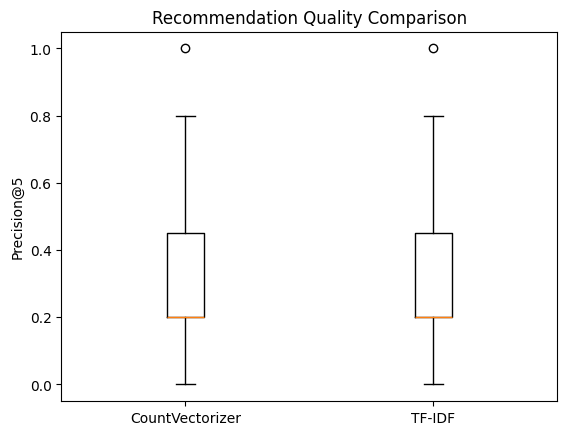

In [71]:
import matplotlib.pyplot as plt

plt.boxplot([precs_count, precs_tfidf], labels=['CountVectorizer', 'TF-IDF'])
plt.ylabel('Precision@5')
plt.title('Recommendation Quality Comparison')
plt.show()

In [72]:
print(new_df.columns.tolist())

['movie_id', 'title', 'tags']


In [73]:
print(new_df.head(3))

   movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   
2    206647                                   Spectre   

                                                tags  
0  in the 22nd century, a parapleg marin is dispa...  
1  captain barbossa, long believ to be dead, ha c...  
2  a cryptic messag from bond’ past send him on a...  


In [74]:
import numpy as np
import pandas as pd

# --- Basic dataset info
num_movies = len(new_df)
avg_tag_length = np.mean(new_df['tags'].apply(lambda x: len(x.split())))
max_tag_length = np.max(new_df['tags'].apply(lambda x: len(x.split())))
min_tag_length = np.min(new_df['tags'].apply(lambda x: len(x.split())))

# --- Vocabulary-level info
all_words = [word for text in new_df['tags'] for word in text.split()]
vocab_size = len(set(all_words))

# --- Average word frequency per movie
avg_unique_words_per_movie = np.mean(new_df['tags'].apply(lambda x: len(set(x.split()))))

print("=== Dataset Statistics ===")
print(f"Total Movies: {num_movies}")
print(f"Vocabulary Size: {vocab_size}")
print(f"Average Tag Length: {avg_tag_length:.2f} words/movie")
print(f"Average Unique Words/Movie: {avg_unique_words_per_movie:.2f}")
print(f"Shortest Tag: {min_tag_length} words")
print(f"Longest Tag: {max_tag_length} words")

=== Dataset Statistics ===
Total Movies: 4806
Vocabulary Size: 43268
Average Tag Length: 66.22 words/movie
Average Unique Words/Movie: 55.33
Shortest Tag: 3 words
Longest Tag: 200 words


In [75]:
from collections import Counter
word_counts = Counter(all_words)
most_common = word_counts.most_common(10)
print("Top 10 most frequent words:", most_common)

Top 10 most frequent words: [('the', 13802), ('a', 10450), ('to', 7921), ('and', 7340), ('of', 6872), ('in', 4509), ('hi', 4000), ('is', 3340), ('with', 2527), ('drama', 2363)]


In [76]:
tag_lengths = new_df['tags'].apply(lambda x: len(x.split()))
print(tag_lengths.describe())

count    4806.000000
mean       66.216604
std        28.669154
min         3.000000
25%        44.000000
50%        63.000000
75%        82.000000
max       200.000000
Name: tags, dtype: float64


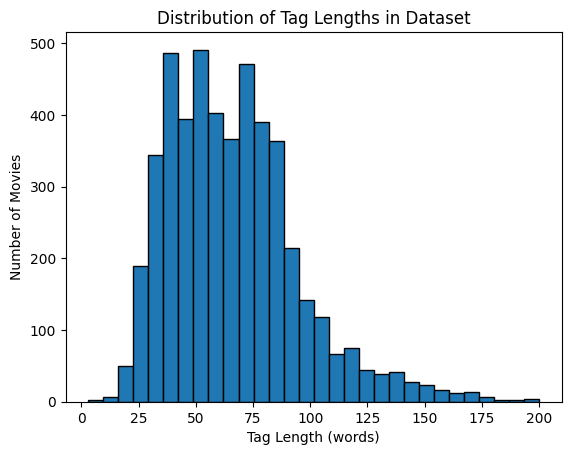

In [77]:
import matplotlib.pyplot as plt
plt.hist(tag_lengths, bins=30, edgecolor='black')
plt.xlabel('Tag Length (words)')
plt.ylabel('Number of Movies')
plt.title('Distribution of Tag Lengths in Dataset')
plt.show()